In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train = pd.read_csv("Dataset/Train.csv")
test  = pd.read_csv("Dataset/Test.csv")

In [3]:
train.shape

(1462, 5)

In [4]:
train.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [5]:
test.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [6]:
train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [7]:
train["date"] = pd.to_datetime(train["date"])
test["date"]  = pd.to_datetime(test["date"])
train = train.sort_values("date").reset_index(drop=True)
test  = test.sort_values("date").reset_index(drop=True)


In [8]:
train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [9]:
test.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [10]:
print(train["meantemp"].describe())


count    1462.000000
mean       25.495521
std         7.348103
min         6.000000
25%        18.857143
50%        27.714286
75%        31.305804
max        38.714286
Name: meantemp, dtype: float64


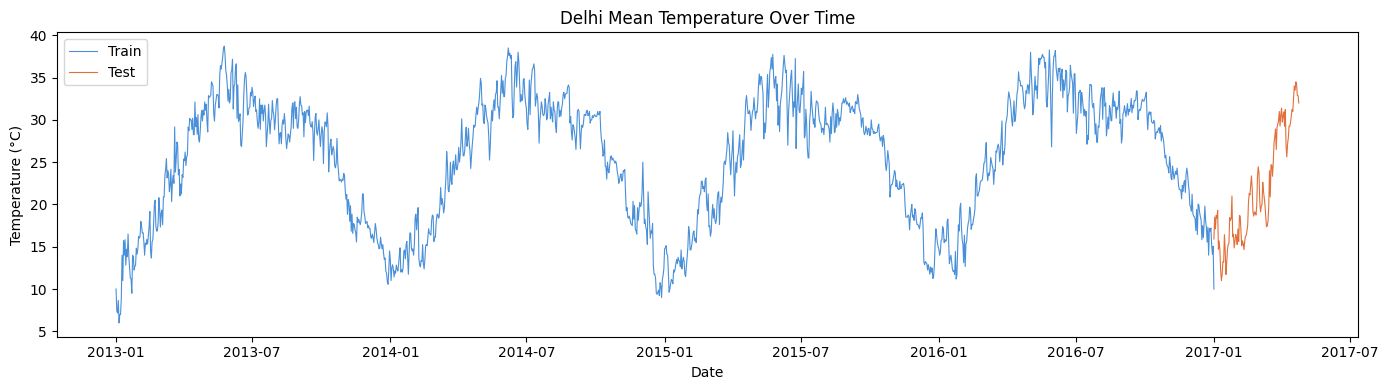

In [11]:
plt.figure(figsize=(14, 4))
plt.plot(train["date"], train["meantemp"], linewidth=0.8, color="#4A90D9", label="Train")
plt.plot(test["date"],  test["meantemp"],  linewidth=0.8, color="#E2703A", label="Test")
plt.title("Delhi Mean Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

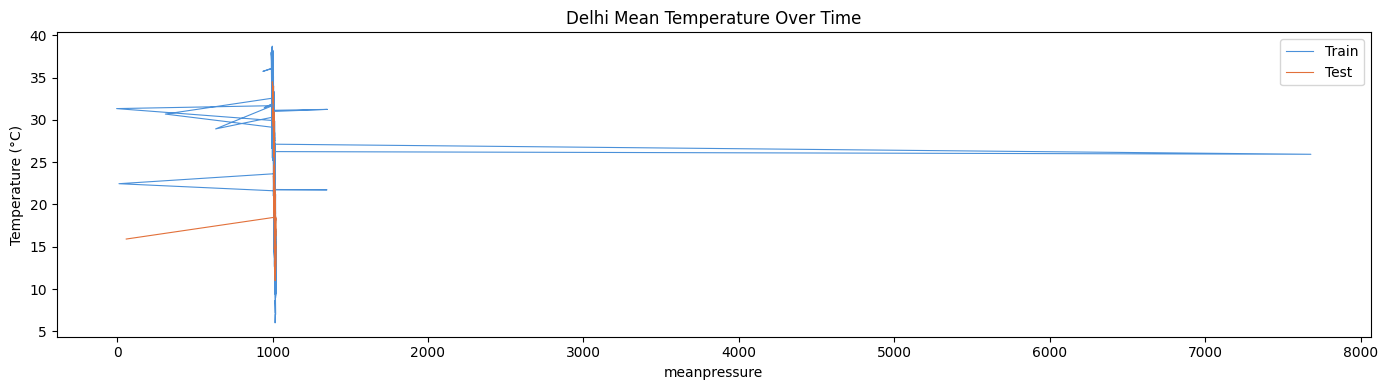

In [12]:
plt.figure(figsize=(14, 4))
plt.plot(train["meanpressure"], train["meantemp"], linewidth=0.8, color="#4A90D9", label="Train")
plt.plot(test["meanpressure"],  test["meantemp"],  linewidth=0.8, color="#E2703A", label="Test")
plt.title("Delhi Mean Temperature Over Time")
plt.xlabel("meanpressure")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

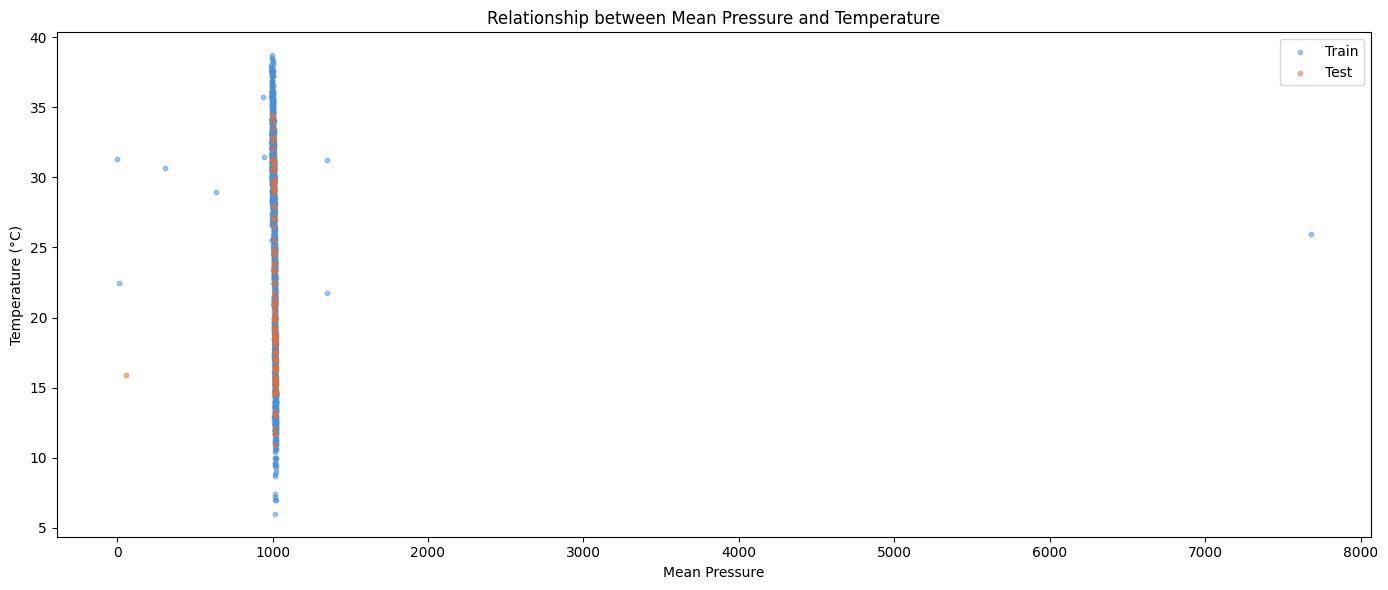

In [13]:
plt.figure(figsize=(14, 6))

# Scatter plot for Train data
plt.scatter(train["meanpressure"], train["meantemp"], 
            color="#4A90D9", label="Train", s=10, alpha=0.5)

# Scatter plot for Test data
plt.scatter(test["meanpressure"], test["meantemp"], 
            color="#E2703A", label="Test", s=10, alpha=0.5)

plt.title("Relationship between Mean Pressure and Temperature")
plt.xlabel("Mean Pressure")
plt.ylabel("Temperature (°C)")
plt.legend()

# Optional: Set x-axis limits if outliers (like that 8000 value) hide the main data
# plt.xlim(950, 1050) 

plt.tight_layout()
plt.show()

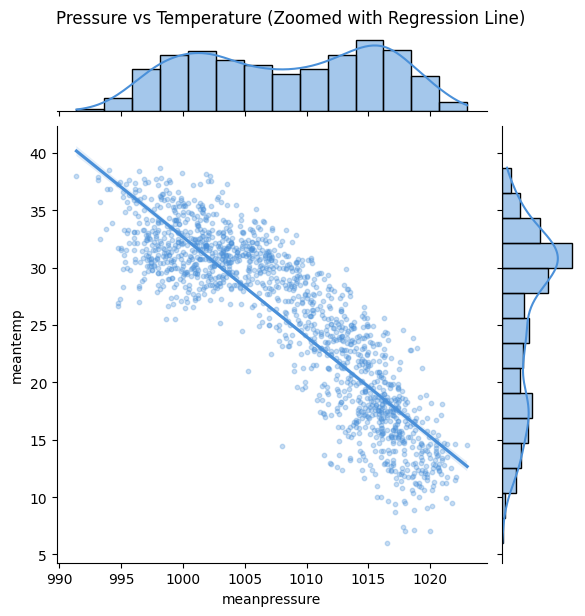

In [14]:
import seaborn as sns

# Filtering to the realistic range of atmospheric pressure
filtered_train = train[(train["meanpressure"] > 950) & (train["meanpressure"] < 1050)]

grid = sns.jointplot(data=filtered_train, x="meanpressure", y="meantemp", 
                   kind="reg", color="#4A90D9", scatter_kws={'alpha':0.3, 's':10})
grid.fig.suptitle("Pressure vs Temperature (Zoomed with Regression Line)", y=1.02)
plt.show()

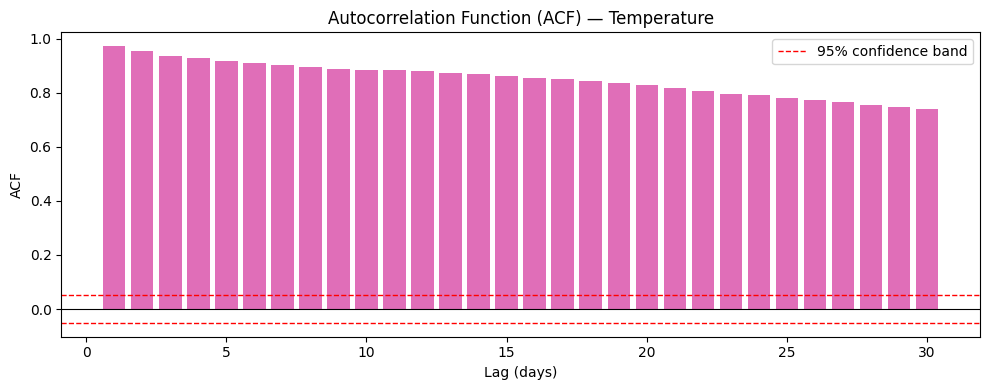

In [15]:
temps = train["meantemp"].values
 
def compute_acf(series, nlags=12):
    
    n    = len(series)
    mean = series.mean()
    var  = ((series - mean) ** 2).mean()
    acf_vals = []
    for lag in range(1, nlags + 1):
        cov = ((series[: n - lag] - mean) * (series[lag:] - mean)).mean()
        acf_vals.append(cov / var)
    return acf_vals
 
acf_values = compute_acf(temps, nlags=30)
lags       = list(range(1, 31))
 
plt.figure(figsize=(10, 4))
plt.bar(lags, acf_values, color="#D94AA7", alpha=0.8)
plt.axhline(y=0,    color="black", linewidth=0.8)
plt.axhline(y= 1.96 / np.sqrt(len(temps)), color="red",
            linestyle="--", linewidth=1, label="95% confidence band")
plt.axhline(y=-1.96 / np.sqrt(len(temps)), color="red",
            linestyle="--", linewidth=1)
plt.title("Autocorrelation Function (ACF) — Temperature")
plt.xlabel("Lag (days)")
plt.ylabel("ACF")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:

lag_acf_pairs = list(zip(lags, acf_values))

sorted_lags = sorted(lag_acf_pairs, key=lambda x: abs(x[1]), reverse=True)

top_10_lags = sorted_lags[:30]

print("Top 10 Lags (Lag, ACF value):")
for lag, val in top_10_lags:
    print(f"Lag {lag}: {val:.4f}")

Top 10 Lags (Lag, ACF value):
Lag 1: 0.9718
Lag 2: 0.9523
Lag 3: 0.9363
Lag 4: 0.9271
Lag 5: 0.9187
Lag 6: 0.9111
Lag 7: 0.9028
Lag 8: 0.8954
Lag 9: 0.8890
Lag 10: 0.8846
Lag 11: 0.8828
Lag 12: 0.8783
Lag 13: 0.8735
Lag 14: 0.8681
Lag 15: 0.8627
Lag 16: 0.8556
Lag 17: 0.8488
Lag 18: 0.8415
Lag 19: 0.8353
Lag 20: 0.8273
Lag 21: 0.8173
Lag 22: 0.8069
Lag 23: 0.7965
Lag 24: 0.7894
Lag 25: 0.7809
Lag 26: 0.7728
Lag 27: 0.7640
Lag 28: 0.7560
Lag 29: 0.7482
Lag 30: 0.7400


In [17]:
temps_diff = np.diff(temps)
acf_values = compute_acf(temps_diff, nlags=30)
lags = list(range(1, 31))

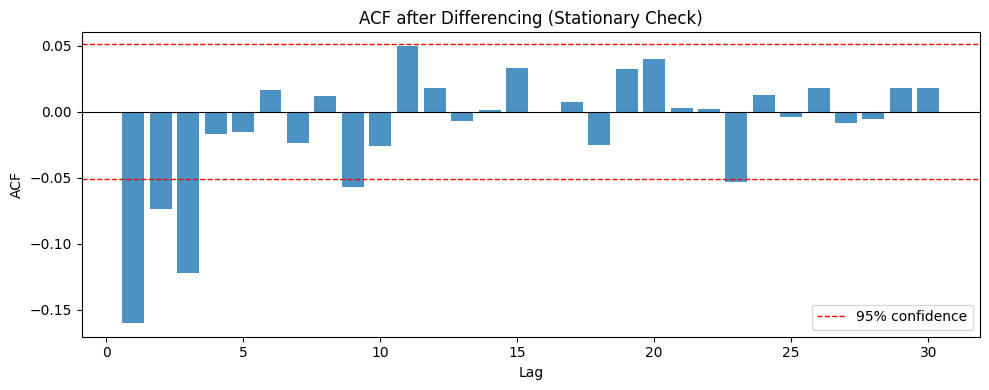

In [18]:
plt.figure(figsize=(10, 4))

plt.bar(lags, acf_values, alpha=0.8)

plt.axhline(y=0, color="black", linewidth=0.8)

conf = 1.96 / np.sqrt(len(temps_diff))
plt.axhline(y= conf, color="red", linestyle="--", linewidth=1, label="95% confidence")
plt.axhline(y=-conf, color="red", linestyle="--", linewidth=1)

plt.title("ACF after Differencing (Stationary Check)")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:

lag_acf_pairs = list(zip(lags, acf_values))

sorted_lags = sorted(lag_acf_pairs, key=lambda x: abs(x[1]), reverse=True)

top_10_lags = sorted_lags[:5]

print("Top 10 Lags (Lag, ACF value):")
for lag, val in top_10_lags:
    print(f"Lag {lag}: {val:.4f}")

Top 10 Lags (Lag, ACF value):
Lag 1: -0.1600
Lag 3: -0.1219
Lag 2: -0.0733
Lag 9: -0.0567
Lag 23: -0.0532


In [20]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


def clean_climate_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    mask = (df["meanpressure"] < 900) | (df["meanpressure"] > 1100)
    df.loc[mask, "meanpressure"] = np.nan
    df["meanpressure"] = (
        df["meanpressure"]
        .fillna(df["meanpressure"].rolling(window=7, min_periods=1, center=True).median())
        .ffill()
        .bfill()
    )
    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    target = "meantemp"
    for col in ["meantemp", "humidity", "wind_speed", "meanpressure"]:
        for lag in [1, 2, 3, 7]:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)
    for window in [7, 14]:
        rolled = df[target].shift(1).rolling(window=window)
        df[f"temp_roll_mean_{window}"] = rolled.mean()
        df[f"temp_roll_std_{window}"]  = rolled.std()
    doy = df["date"].dt.dayofyear
    df["sin_day"] = np.sin(2 * np.pi * doy / 365.25)
    df["cos_day"] = np.cos(2 * np.pi * doy / 365.25)
    df["temp_humidity_index"] = df["meantemp_lag_1"] * df["humidity"] / 100
    df = df.dropna().reset_index(drop=True)
    return df


def engineer_features_test(train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    seed_rows = 15
    tail = train_df.tail(seed_rows).copy()
    combined = pd.concat([tail, test_df], ignore_index=True)
    combined_featured = engineer_features(combined)
    test_dates = set(test_df["date"])
    return combined_featured[combined_featured["date"].isin(test_dates)].reset_index(drop=True)


def prepare_sequences(df, window_size=30, x_scaler=None, y_scaler=None):
    data = df.drop(columns=["date"])
    target_col = "meantemp"
    feature_cols = [c for c in data.columns if c != target_col]
    X_raw = data[feature_cols].values
    y_raw = data[[target_col]].values
    if x_scaler is None:
        x_scaler = StandardScaler()
        X_scaled = x_scaler.fit_transform(X_raw)
    else:
        X_scaled = x_scaler.transform(X_raw)
    if y_scaler is None:
        y_scaler = StandardScaler()
        y_scaled = y_scaler.fit_transform(y_raw).flatten()
    else:
        y_scaled = y_scaler.transform(y_raw).flatten()
    X_seq, y_seq = [], []
    for i in range(window_size, len(X_scaled)):
        X_seq.append(X_scaled[i - window_size:i])
        y_seq.append(y_scaled[i])
    return np.array(X_seq), np.array(y_seq), x_scaler, y_scaler


def inverse_transform_predictions(y_pred_scaled, y_scaler):
    return y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()


def build_pipeline(train_path="Train.csv", test_path="Test.csv", window_size=30):
    train_raw = clean_climate_data(pd.read_csv(train_path))
    test_raw  = clean_climate_data(pd.read_csv(test_path))
    train_feat = engineer_features(train_raw)
    test_feat  = engineer_features_test(train_raw, test_raw)
    X_train, y_train, x_scaler, y_scaler = prepare_sequences(train_feat, window_size)
    X_test, y_test, _, _ = prepare_sequences(test_feat, window_size,
                                              x_scaler=x_scaler, y_scaler=y_scaler)
    print("── Pipeline complete ──────────────────────────────────")
    print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
    print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")
    print(f"  Features: {X_train.shape[2]}  |  Window: {window_size} days")
    print("───────────────────────────────────────────────────────")
    return X_train, y_train, X_test, y_test, x_scaler, y_scaler

print("All pipeline functions defined successfully.")

All pipeline functions defined successfully.

In [21]:
X_train, y_train, X_test, y_test, x_scaler, y_scaler = build_pipeline(
    train_path="Dataset/Train.csv",
    test_path="Dataset/Test.csv",
    window_size=30
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

── Pipeline complete ──────────────────────────────────
  X_train : (1418, 30, 26)   y_train : (1418,)
  X_test  : (85, 30, 26)    y_test  : (85,)
  Features: 26  |  Window: 30 days
───────────────────────────────────────────────────────
X_train: (1418, 30, 26)
X_test:  (85, 30, 26)


In [22]:
train_raw = clean_climate_data(pd.read_csv("Dataset/Train.csv"))
test_raw  = clean_climate_data(pd.read_csv("Dataset/Test.csv"))

train_feat = engineer_features(train_raw)
test_feat  = engineer_features_test(train_raw, test_raw)

print(train_feat.shape)
train_feat.head(10)

(1448, 28)


,date,meantemp,humidity,wind_speed,meanpressure,meantemp_lag_1,meantemp_lag_2,meantemp_lag_3,meantemp_lag_7,humidity_lag_1,...,meanpressure_lag_2,meanpressure_lag_3,meanpressure_lag_7,temp_roll_mean_7,temp_roll_std_7,temp_roll_mean_14,temp_roll_std_14,sin_day,cos_day,temp_humidity_index
0,2013-01-15,14.714286,71.857143,0.528571,1015.857143,12.833333,15.833333,14.000000,8.857143,88.166667,...,1013.333333,1015.571429,1018.714286,13.176871,2.528741,10.390816,3.480075,0.255182,0.966893,9.221667
1,2013-01-16,13.833333,86.666667,0.000000,1016.666667,14.714286,12.833333,15.833333,14.000000,71.857143,...,1015.166667,1013.333333,1017.000000,14.013605,1.691642,10.727551,3.662640,0.271777,0.962360,12.752381
2,2013-01-17,16.500000,80.833333,5.250000,1015.833333,13.833333,14.714286,12.833333,11.000000,86.666667,...,1015.857143,1015.166667,1015.666667,13.989796,1.693037,11.187075,3.616322,0.288291,0.957543,11.181944
3,2013-01-18,13.833333,92.166667,8.950000,1014.500000,16.500000,13.833333,14.714286,15.714286,80.833333,...,1016.666667,1015.857143,1016.142857,14.775510,1.306335,11.853741,3.677922,0.304719,0.952442,15.207500
4,2013-01-19,12.500000,76.666667,5.883333,1021.666667,13.833333,16.500000,13.833333,14.000000,92.166667,...,1015.833333,1016.666667,1015.571429,14.506803,1.274104,12.222789,3.591732,0.321058,0.947060,10.605556
5,2013-01-20,11.285714,75.285714,8.471429,1020.285714,12.500000,13.833333,16.500000,15.833333,76.666667,...,1014.500000,1015.833333,1013.333333,14.292517,1.482623,12.687075,3.113777,0.337301,0.941397,9.410714
6,2013-01-21,11.200000,77.000000,2.220000,1021.000000,11.285714,12.500000,13.833333,12.833333,75.285714,...,1021.666667,1014.500000,1015.166667,13.642857,1.678360,12.993197,2.694038,0.353445,0.935455,8.690000
7,2013-01-22,9.500000,79.666667,3.083333,1021.800000,11.200000,11.285714,12.500000,14.714286,77.000000,...,1020.285714,1021.666667,1015.857143,13.409524,1.907550,13.293197,2.155299,0.369484,0.929237,8.922667
8,2013-01-23,14.000000,60.166667,4.016667,1020.500000,9.500000,11.200000,11.285714,13.833333,79.666667,...,1021.000000,1020.285714,1016.666667,12.664626,2.292391,13.339116,2.058180,0.385413,0.922744,5.715833
9,2013-01-24,13.833333,60.666667,6.166667,1020.500000,14.000000,9.500000,11.200000,16.500000,60.166667,...,1021.800000,1021.000000,1015.833333,12.688435,2.307369,13.339116,2.058180,0.401229,0.915978,8.493333


In [23]:
import pandas as pd

feature_cols = [c for c in train_feat.columns if c not in ['date', 'meantemp']]

pd.DataFrame(X_train[0], columns=feature_cols)   

,humidity,wind_speed,meanpressure,meantemp_lag_1,meantemp_lag_2,meantemp_lag_3,meantemp_lag_7,humidity_lag_1,humidity_lag_2,humidity_lag_3,...,meanpressure_lag_2,meanpressure_lag_3,meanpressure_lag_7,temp_roll_mean_7,temp_roll_std_7,temp_roll_mean_14,temp_roll_std_14,sin_day,cos_day,temp_humidity_index
0,0.670438,-1.378070,0.994915,-1.774956,-1.359500,-1.613517,-2.318391,1.646909,0.870504,0.802001,...,0.672215,0.959337,1.361795,-1.763481,1.581892,-2.168437,2.649628,0.361071,1.386004,-1.183071
1,1.555199,-1.493936,1.098585,-1.514335,-1.775218,-1.359471,-1.607630,0.671581,1.648384,0.871868,...,0.907062,0.672575,1.142171,-1.645095,0.357693,-2.120503,2.929977,0.384439,1.379566,-0.449390
2,1.206700,-0.343102,0.991866,-1.636398,-1.514569,-1.775183,-2.022240,1.557208,0.672472,1.650389,...,0.995511,0.907476,0.971353,-1.648464,0.359734,-2.055089,2.858850,0.407694,1.372723,-0.775726
3,1.883784,0.467962,0.821116,-1.266909,-1.636645,-1.514538,-1.370709,1.208368,1.558629,0.673674,...,1.099210,0.995945,1.032360,-1.537296,-0.205791,-1.960189,2.953444,0.430829,1.365478,0.060783
4,0.957772,-0.204271,1.738899,-1.636398,-1.267118,-1.636612,-1.607630,1.886114,1.209580,1.560559,...,0.992461,1.099668,0.959152,-1.575315,-0.252927,-1.907655,2.821090,0.453836,1.357833,-0.895499
5,0.875270,0.363056,1.562050,-1.821142,-1.636645,-1.267090,-1.354257,0.959196,1.887732,1.211223,...,0.821663,0.992894,0.672421,-1.605633,0.052017,-1.841563,2.087140,0.476710,1.349789,-1.143787
6,0.977686,-1.007298,1.653524,-1.989391,-1.821409,-1.636612,-1.768867,0.876614,0.960259,1.889933,...,1.739702,0.822057,0.907296,-1.697550,0.338270,-1.797986,1.442587,0.499444,1.341350,-1.293551
7,1.137000,-0.818049,1.755974,-2.001268,-1.989676,-1.821373,-1.508913,0.979130,0.877627,0.961698,...,1.562804,1.740306,0.995756,-1.730564,0.673443,-1.755281,0.615297,0.522030,1.332517,-1.245203
8,-0.027984,-0.613457,1.589492,-2.236817,-2.001554,-1.989638,-1.630664,1.138600,0.980205,0.878998,...,1.654303,1.563368,1.099467,-1.835956,1.236247,-1.748745,0.466160,0.544462,1.323294,-1.911581
9,0.001888,-0.142163,1.589492,-1.613305,-2.237127,-2.001515,-1.262121,-0.027522,1.139770,0.981660,...,1.756782,1.654888,0.992705,-1.832587,1.258151,-1.748745,0.466160,0.566733,1.313683,-1.334418


In [24]:
train_feat.to_csv("train_featured.csv", index=False)
test_feat.to_csv("test_featured.csv", index=False)

print("Saved train_featured.csv:", train_feat.shape)
print("Saved test_featured.csv:", test_feat.shape)

Saved train_featured.csv: (1448, 28)
Saved test_featured.csv: (115, 28)


In [25]:
train_feat.describe()        
train_feat.info()             

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1448 entries, 0 to 1447
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 1448 non-null   datetime64[ns]
 1   meantemp             1448 non-null   float64       
 2   humidity             1448 non-null   float64       
 3   wind_speed           1448 non-null   float64       
 4   meanpressure         1448 non-null   float64       
 5   meantemp_lag_1       1448 non-null   float64       
 6   meantemp_lag_2       1448 non-null   float64       
 7   meantemp_lag_3       1448 non-null   float64       
 8   meantemp_lag_7       1448 non-null   float64       
 9   humidity_lag_1       1448 non-null   float64       
 10  humidity_lag_2       1448 non-null   float64       
 11  humidity_lag_3       1448 non-null   float64       
 12  humidity_lag_7       1448 non-null   float64       
 13  wind_speed_lag_1     1448 non-nul

In [26]:
y_train_celsius = inverse_transform_predictions(y_train, y_scaler)

pd.Series(y_train_celsius, name="meantemp_°C").describe()

count    1418.000000
mean       25.875426
std         7.110693
min         9.000000
25%        19.750000
50%        28.142857
75%        31.421429
max        38.714286
Name: meantemp_°C, dtype: float64

C:\Users\Asus\AppData\Local\Temp\ipykernel_62836\1681505278.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_feat, x="month", y="meantemp", ax=ax3,


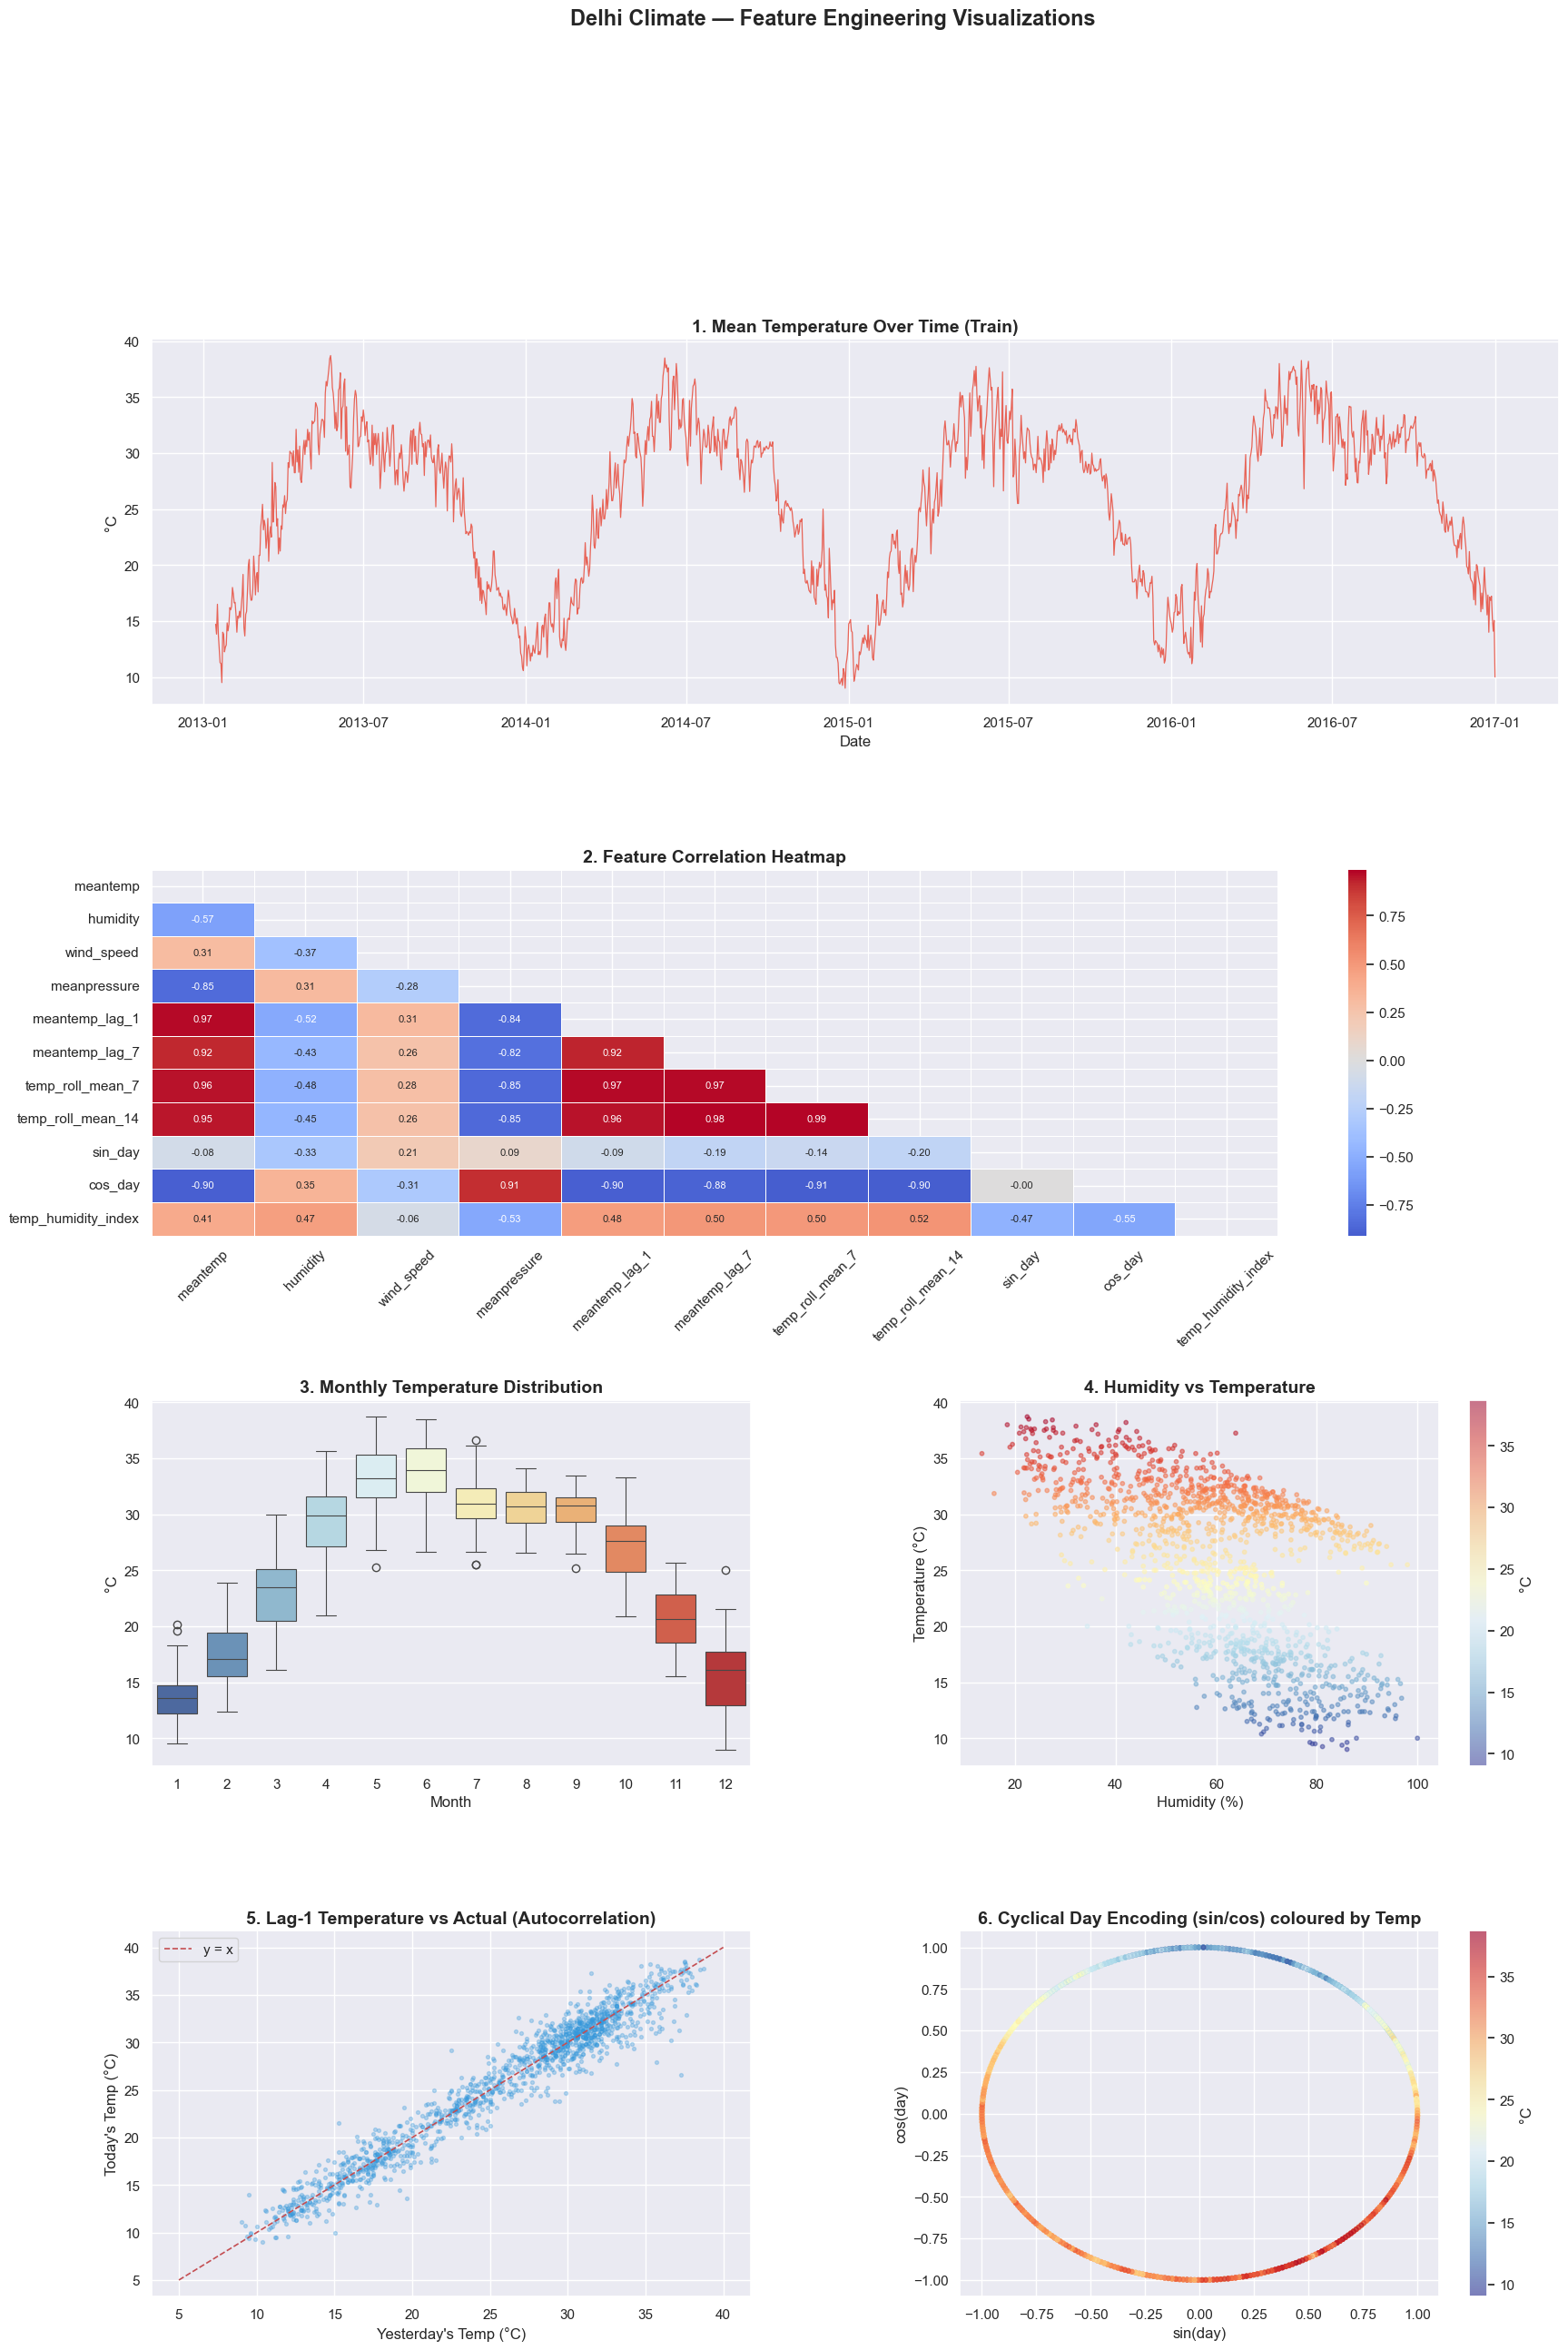

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid")
fig = plt.figure(figsize=(20, 28))
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)


ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train_feat["date"], train_feat["meantemp"], color="#e74c3c", linewidth=0.9, alpha=0.85)
ax1.set_title("1. Mean Temperature Over Time (Train)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Date"); ax1.set_ylabel("°C")

ax2 = fig.add_subplot(gs[1, :])
corr_cols = ["meantemp", "humidity", "wind_speed", "meanpressure",
             "meantemp_lag_1", "meantemp_lag_7",
             "temp_roll_mean_7", "temp_roll_mean_14",
             "sin_day", "cos_day", "temp_humidity_index"]
corr = train_feat[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax2, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, annot_kws={"size": 8})
ax2.set_title("2. Feature Correlation Heatmap", fontsize=14, fontweight="bold")
ax2.tick_params(axis="x", rotation=45)

ax3 = fig.add_subplot(gs[2, 0])
train_feat["month"] = train_feat["date"].dt.month
sns.boxplot(data=train_feat, x="month", y="meantemp", ax=ax3,
            palette="RdYlBu_r", linewidth=0.8)
ax3.set_title("3. Monthly Temperature Distribution", fontsize=14, fontweight="bold")
ax3.set_xlabel("Month"); ax3.set_ylabel("°C")

ax4 = fig.add_subplot(gs[2, 1])
sc = ax4.scatter(train_feat["humidity"], train_feat["meantemp"],
                 c=train_feat["meantemp"], cmap="RdYlBu_r", alpha=0.5, s=10)
plt.colorbar(sc, ax=ax4, label="°C")
ax4.set_title("4. Humidity vs Temperature", fontsize=14, fontweight="bold")
ax4.set_xlabel("Humidity (%)"); ax4.set_ylabel("Temperature (°C)")

ax5 = fig.add_subplot(gs[3, 0])
ax5.scatter(train_feat["meantemp_lag_1"], train_feat["meantemp"],
            alpha=0.3, s=8, color="#3498db")
ax5.plot([5, 40], [5, 40], "r--", linewidth=1.2, label="y = x")
ax5.set_title("5. Lag-1 Temperature vs Actual (Autocorrelation)", fontsize=14, fontweight="bold")
ax5.set_xlabel("Yesterday's Temp (°C)"); ax5.set_ylabel("Today's Temp (°C)")
ax5.legend()

ax6 = fig.add_subplot(gs[3, 1])
sc2 = ax6.scatter(train_feat["sin_day"], train_feat["cos_day"],
                  c=train_feat["meantemp"], cmap="RdYlBu_r", alpha=0.6, s=12)
plt.colorbar(sc2, ax=ax6, label="°C")
ax6.set_title("6. Cyclical Day Encoding (sin/cos) coloured by Temp", fontsize=14, fontweight="bold")
ax6.set_xlabel("sin(day)"); ax6.set_ylabel("cos(day)")

plt.suptitle("Delhi Climate — Feature Engineering Visualizations", fontsize=17, fontweight="bold", y=1.01)
plt.show()


In [28]:
train_df = pd.read_csv("train_featured.csv")
test_df = pd.read_csv("test_featured.csv")

In [29]:
train_df.isnull().sum()

date                   0
meantemp               0
humidity               0
wind_speed             0
meanpressure           0
meantemp_lag_1         0
meantemp_lag_2         0
meantemp_lag_3         0
meantemp_lag_7         0
humidity_lag_1         0
humidity_lag_2         0
humidity_lag_3         0
humidity_lag_7         0
wind_speed_lag_1       0
wind_speed_lag_2       0
wind_speed_lag_3       0
wind_speed_lag_7       0
meanpressure_lag_1     0
meanpressure_lag_2     0
meanpressure_lag_3     0
meanpressure_lag_7     0
temp_roll_mean_7       0
temp_roll_std_7        0
temp_roll_mean_14      0
temp_roll_std_14       0
sin_day                0
cos_day                0
temp_humidity_index    0
dtype: int64

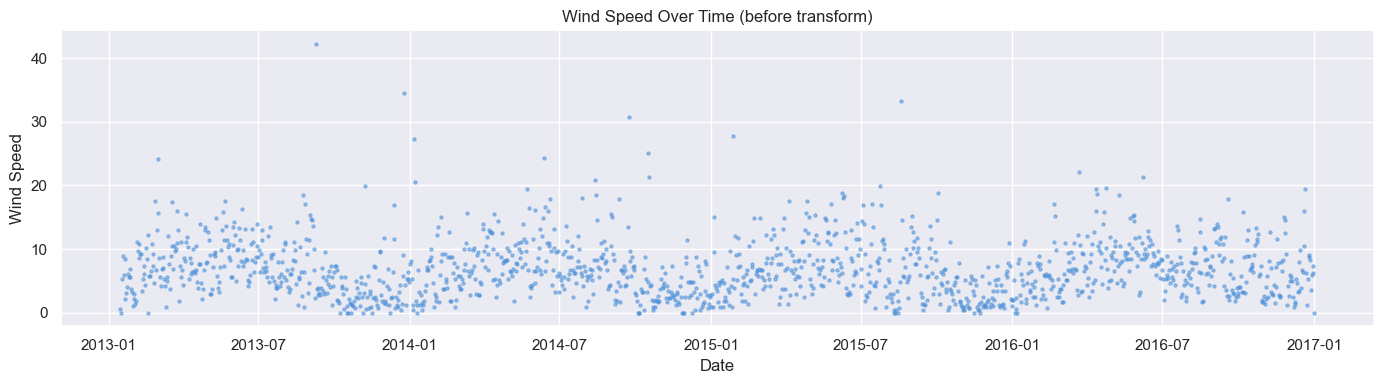

In [30]:
train_df["date"] = pd.to_datetime(train_df["date"])
plt.figure(figsize=(14, 4))
plt.scatter(train_df["date"], train_df["wind_speed"], s=5, alpha=0.5, color="#4A90D9")
plt.title("Wind Speed Over Time (before transform)")
plt.xlabel("Date")
plt.ylabel("Wind Speed")
plt.tight_layout()
plt.show()

In [31]:
import numpy as np

# Reload clean featured data first to avoid double-transform
train_feat = pd.read_csv("train_featured.csv")
test_feat  = pd.read_csv("test_featured.csv")

# Drop month col if present
train_feat = train_feat.drop(columns=["month"], errors="ignore")
test_feat  = test_feat.drop(columns=["month"], errors="ignore")

# 1. Log-transform wind speed (fixes right skew of 1.44)
for col in ["wind_speed", "wind_speed_lag_1", "wind_speed_lag_2",
            "wind_speed_lag_3", "wind_speed_lag_7"]:
    train_feat[col] = np.log1p(train_feat[col])
    test_feat[col]  = np.log1p(test_feat[col])

# 2. Clip pressure outliers to realistic Delhi range
for col in ["meanpressure", "meanpressure_lag_1", "meanpressure_lag_2",
            "meanpressure_lag_3", "meanpressure_lag_7"]:
    train_feat[col] = train_feat[col].clip(lower=970, upper=1025)
    test_feat[col]  = test_feat[col].clip(lower=970, upper=1025)

# 3. Log-transform rolling std (reduces outlier spikes)
for col in ["temp_roll_std_7", "temp_roll_std_14"]:
    train_feat[col] = np.log1p(train_feat[col])
    test_feat[col]  = np.log1p(test_feat[col])

# 4. Add new features
train_feat["temp_change_7d"]      = train_feat["meantemp"] - train_feat["meantemp_lag_7"]
test_feat["temp_change_7d"]       = test_feat["meantemp"]  - test_feat["meantemp_lag_7"]

train_feat["wind_pressure_index"] = train_feat["wind_speed_lag_1"] * train_feat["meanpressure_lag_1"] / 1000
test_feat["wind_pressure_index"]  = test_feat["wind_speed_lag_1"]  * test_feat["meanpressure_lag_1"]  / 1000

# Save clean v2
train_feat.to_csv("train_featured_v2.csv", index=False)
test_feat.to_csv("test_featured_v2.csv",   index=False)

print("Done. Train shape:", train_feat.shape)
print("Done. Test shape: ", test_feat.shape)

Done. Train shape: (1448, 30)
Done. Test shape:  (115, 30)


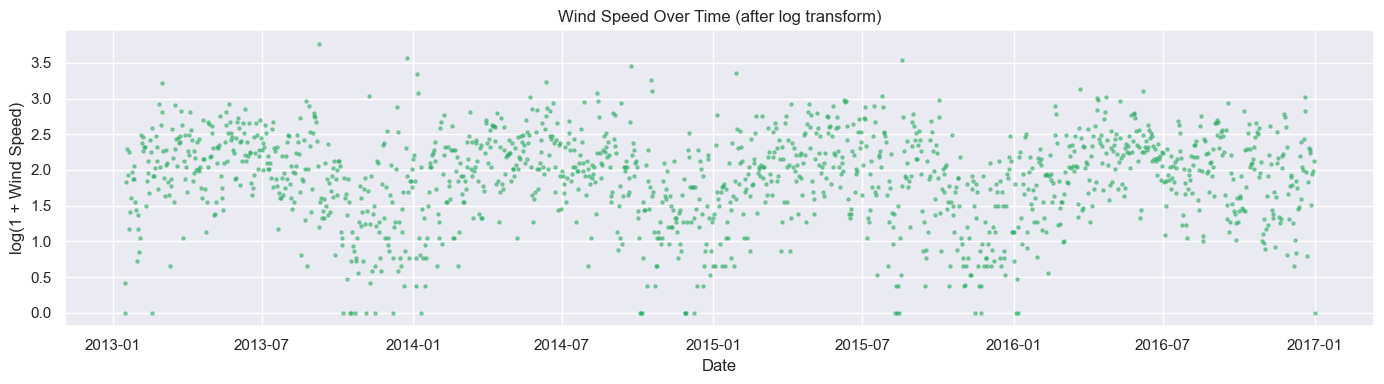

In [32]:
train_feat["date"] = pd.to_datetime(train_feat["date"])
plt.figure(figsize=(14, 4))
plt.scatter(train_feat["date"], train_feat["wind_speed"], s=5, alpha=0.5, color="#27ae60")
plt.title("Wind Speed Over Time (after log transform)")
plt.xlabel("Date")
plt.ylabel("log(1 + Wind Speed)")
plt.tight_layout()
plt.show()

In [33]:
# Confirm final shape after all transforms
print("Train shape:", train_feat.shape)
print("Test shape: ", test_feat.shape)
print("Columns:", list(train_feat.columns))

Train shape: (1448, 30)
Test shape:  (115, 30)
Columns: ['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure', 'meantemp_lag_1', 'meantemp_lag_2', 'meantemp_lag_3', 'meantemp_lag_7', 'humidity_lag_1', 'humidity_lag_2', 'humidity_lag_3', 'humidity_lag_7', 'wind_speed_lag_1', 'wind_speed_lag_2', 'wind_speed_lag_3', 'wind_speed_lag_7', 'meanpressure_lag_1', 'meanpressure_lag_2', 'meanpressure_lag_3', 'meanpressure_lag_7', 'temp_roll_mean_7', 'temp_roll_std_7', 'temp_roll_mean_14', 'temp_roll_std_14', 'sin_day', 'cos_day', 'temp_humidity_index', 'temp_change_7d', 'wind_pressure_index']


In [34]:

print("Train shape:", train_feat.shape)
print("Test shape: ", test_feat.shape)

Train shape: (1448, 30)
Test shape:  (115, 30)


In [35]:
# training part

In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

train_feat = pd.read_csv("train_featured_v2.csv")
test_feat  = pd.read_csv("test_featured_v2.csv")

# Drop month column if it snuck in
train_feat = train_feat.drop(columns=["month"], errors="ignore")
test_feat  = test_feat.drop(columns=["month"], errors="ignore")

TARGET = "meantemp"
feature_cols = [c for c in train_feat.columns if c not in ["date", TARGET]]

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(train_feat[feature_cols])
y_train_scaled = y_scaler.fit_transform(train_feat[[TARGET]]).flatten()

X_test_scaled  = X_scaler.transform(test_feat[feature_cols])
y_test_scaled  = y_scaler.transform(test_feat[[TARGET]]).flatten()

print("Features:", len(feature_cols))
print("Train rows:", len(X_train_scaled), "| Test rows:", len(X_test_scaled))

Features: 28
Train rows: 1448 | Test rows: 115


In [37]:
def make_sequences(X, y, window=30):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

WINDOW = 14              # reduced from 30 → captures sharper daily patterns
X_train, y_train = make_sequences(X_train_scaled, y_train_scaled, WINDOW)
X_test,  y_test  = make_sequences(X_test_scaled,  y_test_scaled,  WINDOW)

print("X_train:", X_train.shape)   # (samples, 14, 28)
print("X_test: ", X_test.shape)    # (samples, 14, 28)

X_train: (1434, 14, 28)
X_test:  (101, 14, 28)


In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
from sklearn.metrics import mean_squared_error
import numpy as np
import random

best_rmse = 999
best_history = None
best_model = None

# Automatically tries 10 different seeds, keeps the best one
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    n_features = X_train.shape[2]

    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation="relu",
               padding="same", input_shape=(WINDOW, n_features)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dense(1)
    ])

    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipvalue=1.0),
        loss=Huber(),
        metrics=["mae"]
    )

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=25,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=10, min_lr=1e-6, verbose=0)
    ]

    m.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=150,
        batch_size=32,
        callbacks=callbacks,
        verbose=1      # silent — no spam output
    )

    # Evaluate on test
    y_pred_s = m.predict(X_test, verbose=0).flatten()
    y_pred_c = y_scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
    y_true_c = y_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_true_c, y_pred_c))

    print(f"Seed {seed:2d} → RMSE: {rmse:.3f}°C")

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = m
        best_history = m.history.history
        best_seed = seed

print(f"\n✅ Best seed: {best_seed}  |  Best RMSE: {best_rmse:.3f}°C")



c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150



 1/41 ━━━━━━━━━━━━━━━━━━━━ 1:22 2s/step - loss: 0.5217 - mae: 0.9286


18/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3171 - mae: 0.6495 


32/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2691 - mae: 0.5866

...


 1/41 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0266 - mae: 0.1800


19/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0315 - mae: 0.1971 


37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0323 - mae: 0.1992


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0332 - mae: 0.2014 - val_loss: 0.0280 - val_mae: 0.1961 - learning_rate: 2.5000e-04


Seed  9 → RMSE: 2.356°C

✅ Best seed: 6  |  Best RMSE: 2.104°C


In [39]:
# Use the best model going forward
model = best_model
history = type('obj', (object,), {'history': best_history})()
model.save("best_cnn_lstm.keras")
print("Model saved.")

Model saved.


In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_scaled = model.predict(X_test).flatten()

# Inverse transform back to °C
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"RMSE : {rmse:.3f} °C")
print(f"MAE  : {mae:.3f} °C")
print(f"MAPE : {mape:.2f} %")


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


RMSE : 2.104 °C
MAE  : 1.744 °C
MAPE : 8.14 %


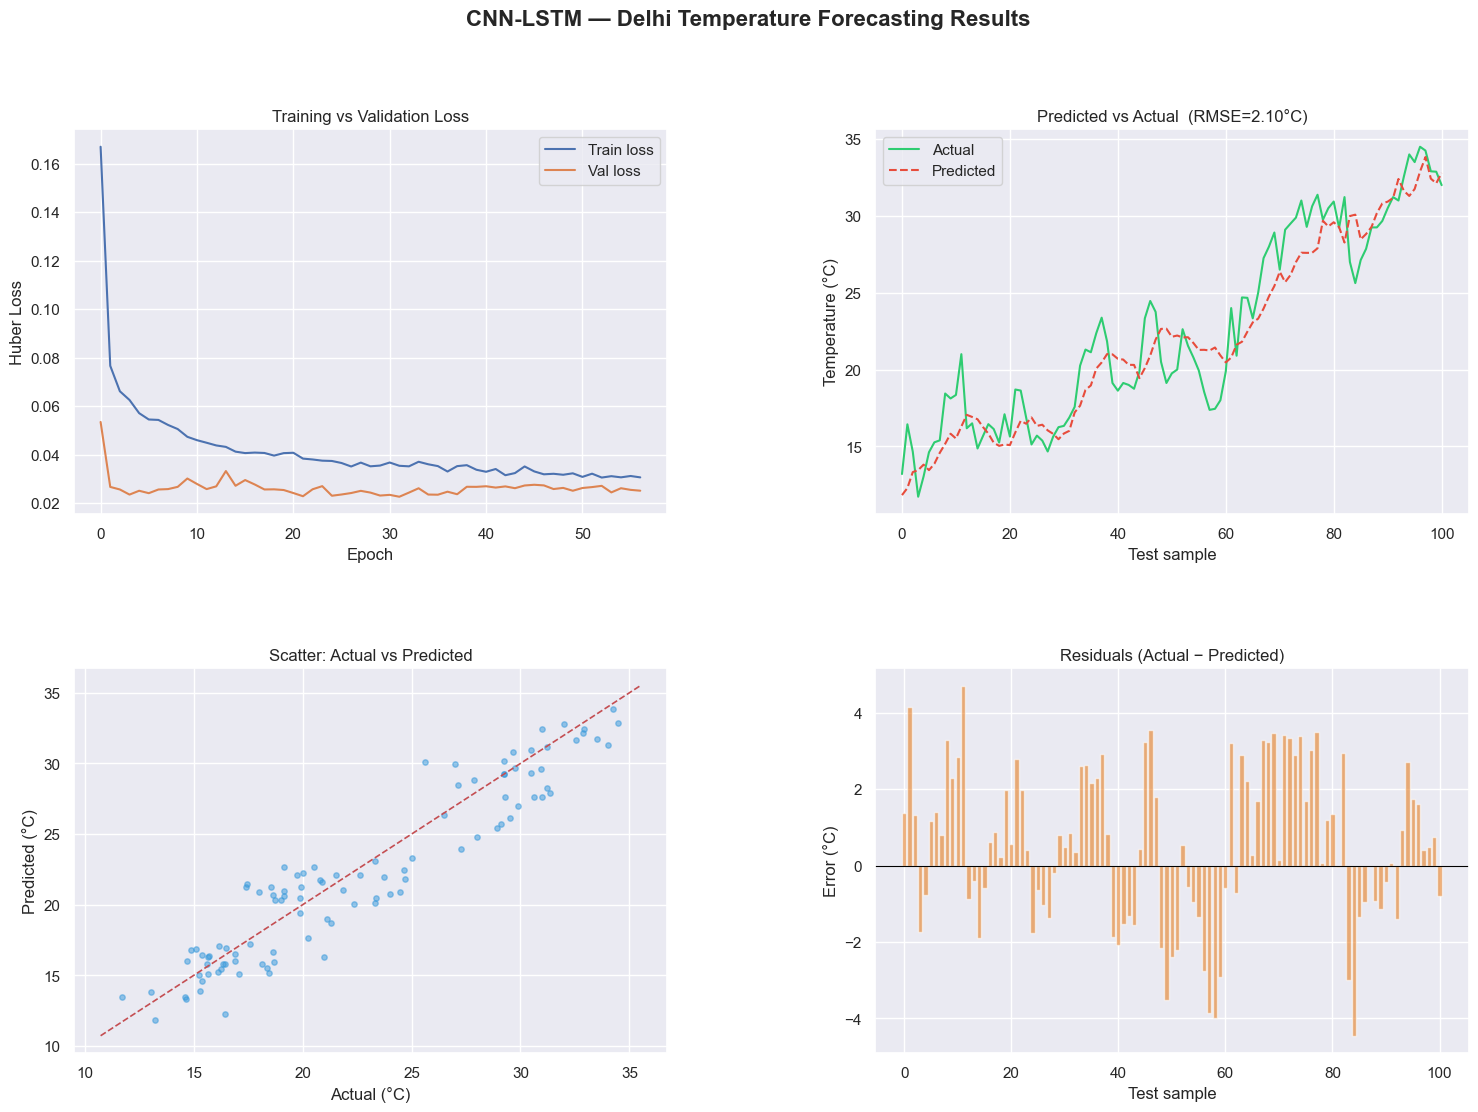

In [41]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# 1. Training loss curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history["loss"],     label="Train loss")
ax1.plot(history.history["val_loss"], label="Val loss")
ax1.set_title("Training vs Validation Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Huber Loss")
ax1.legend()

# 2. Predicted vs Actual
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(y_true, label="Actual",    color="#2ecc71")
ax2.plot(y_pred, label="Predicted", color="#e74c3c", linestyle="--")
ax2.set_title(f"Predicted vs Actual  (RMSE={rmse:.2f}°C)")
ax2.set_xlabel("Test sample"); ax2.set_ylabel("Temperature (°C)")
ax2.legend()

# 3. Scatter: predicted vs actual
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_true, y_pred, alpha=0.5, s=15, color="#3498db")
lims = [min(y_true.min(), y_pred.min())-1, max(y_true.max(), y_pred.max())+1]
ax3.plot(lims, lims, "r--", linewidth=1.2)
ax3.set_title("Scatter: Actual vs Predicted")
ax3.set_xlabel("Actual (°C)"); ax3.set_ylabel("Predicted (°C)")

# 4. Residuals
ax4 = fig.add_subplot(gs[1, 1])
residuals = y_true - y_pred
ax4.bar(range(len(residuals)), residuals, color="#e67e22", alpha=0.6)
ax4.axhline(0, color="black", linewidth=0.8)
ax4.set_title("Residuals (Actual − Predicted)")
ax4.set_xlabel("Test sample"); ax4.set_ylabel("Error (°C)")

plt.suptitle("CNN-LSTM — Delhi Temperature Forecasting Results",
             fontsize=16, fontweight="bold")
plt.savefig("cnn_lstm_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
import numpy as np
import random


random.seed(6)
np.random.seed(6)
tf.random.set_seed(6)

n_features = X_train.shape[2]

model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation="relu",
           padding="same", input_shape=(WINDOW, n_features)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    Dropout(0.3),

    Dense(16, activation="relu"),
    Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss=Huber(), metrics=["mae"])

model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=25,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=10, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

model.save("best_cnn_lstm_seed6.keras")
print("Model saved — seed 6")

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━┳━━━━━━┳━━━━┓
┃ Layer   ┃ Out… ┃ P… ┃
┃ (type)  ┃ Sha… ┃  # ┃
┡━━━━━━━━━╇━━━━━━╇━━━━┩
│ conv1d… │ (No… │ 2… │
│ (Conv1… │ 14,  │    │
│         │ 32)  │    │
├─────────┼──────┼────┤
│ batch_… │ (No… │ 1… │
│ (Batch… │ 14,  │    │
│         │ 32)  │    │
├─────────┼──────┼────┤
│ max_po… │ (No… │  0 │
│ (MaxPo… │ 7,   │    │
│         │ 32)  │    │
├─────────┼──────┼────┤
│ dropou… │ (No… │  0 │
│ (Dropo… │ 7,   │    │
│         │ 32)  │    │
├─────────┼──────┼────┤
│ lstm_10 │ (No… │ 8… │
│ (LSTM)  │ 32)  │    │
├─────────┼──────┼────┤
│ dropou… │ (No… │  0 │
│ (Dropo… │ 32)  │    │
├─────────┼──────┼────┤
│ dense_… │ (No… │ 5… │
│ (Dense) │ 16)  │    │
├─────────┼──────┼────┤
│ dense_… │ (No… │ 17 │
│ (Dense) │ 1)   │    │
└─────────┴──────┴────┘

 Total params: 11,713 (45.75 KB)

 Trainable params: 11,649 (45.50 KB)

...


37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0283 - mae: 0.1853


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0306 - mae: 0.1913 - val_loss: 0.0251 - val_mae: 0.1863 - learning_rate: 1.2500e-04


Epoch 57: early stopping


Restoring model weights from the end of the best epoch: 32.


Model saved — seed 6


In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_scaled = model.predict(X_test).flatten()

# Inverse transform back to °C
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"RMSE : {rmse:.3f} °C")
print(f"MAE  : {mae:.3f} °C")
print(f"MAPE : {mape:.2f} %")


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


RMSE : 2.104 °C
MAE  : 1.744 °C
MAPE : 8.14 %


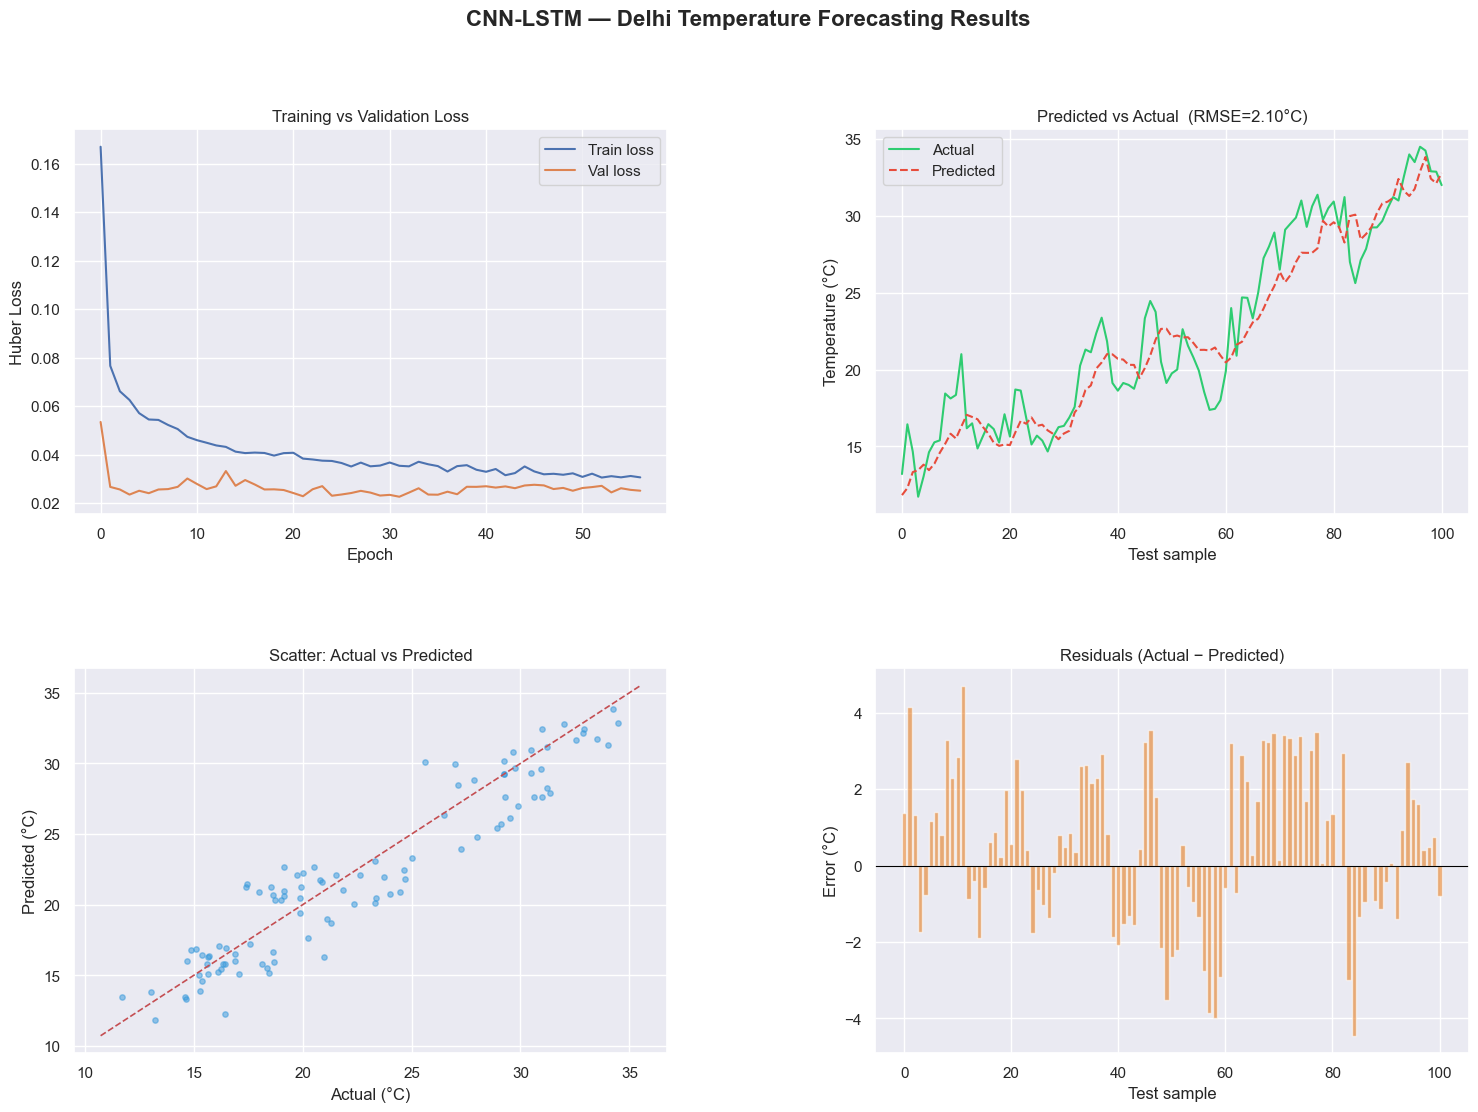

In [44]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# 1. Training loss curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history["loss"],     label="Train loss")
ax1.plot(history.history["val_loss"], label="Val loss")
ax1.set_title("Training vs Validation Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Huber Loss")
ax1.legend()

# 2. Predicted vs Actual
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(y_true, label="Actual",    color="#2ecc71")
ax2.plot(y_pred, label="Predicted", color="#e74c3c", linestyle="--")
ax2.set_title(f"Predicted vs Actual  (RMSE={rmse:.2f}°C)")
ax2.set_xlabel("Test sample"); ax2.set_ylabel("Temperature (°C)")
ax2.legend()

# 3. Scatter: predicted vs actual
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_true, y_pred, alpha=0.5, s=15, color="#3498db")
lims = [min(y_true.min(), y_pred.min())-1, max(y_true.max(), y_pred.max())+1]
ax3.plot(lims, lims, "r--", linewidth=1.2)
ax3.set_title("Scatter: Actual vs Predicted")
ax3.set_xlabel("Actual (°C)"); ax3.set_ylabel("Predicted (°C)")

# 4. Residuals
ax4 = fig.add_subplot(gs[1, 1])
residuals = y_true - y_pred
ax4.bar(range(len(residuals)), residuals, color="#e67e22", alpha=0.6)
ax4.axhline(0, color="black", linewidth=0.8)
ax4.set_title("Residuals (Actual − Predicted)")
ax4.set_xlabel("Test sample"); ax4.set_ylabel("Error (°C)")

plt.suptitle("CNN-LSTM — Delhi Temperature Forecasting Results",
             fontsize=16, fontweight="bold")
plt.show()

In [45]:
import numpy as np

def predict_tomorrow(last_14_days_df, model, x_scaler, y_scaler, feature_cols):
    """
    Pass the last 14 rows of real weather data → get tomorrow's temperature.
    
    last_14_days_df : DataFrame with 14 rows, same columns as train_featured_v2.csv
    """
    # Scale using the same scaler fitted on training data
    X_input = x_scaler.transform(last_14_days_df[feature_cols].values)
    
    # Reshape to (1, 14, n_features) — single sample, 14 timesteps
    X_input = X_input.reshape(1, X_input.shape[0], X_input.shape[1])
    
    # Predict (returns scaled value)
    y_scaled = model.predict(X_input, verbose=0)
    
    # Convert back to °C
    y_celsius = y_scaler.inverse_transform(y_scaled).flatten()[0]
    
    return round(y_celsius, 2)


# Example: use the last 14 rows of your test set as "today's data"
TARGET = "meantemp"
feature_cols = [c for c in train_feat.columns if c not in ["date", TARGET]]

last_14 = test_feat.tail(14).copy()

predicted_temp = predict_tomorrow(last_14, model, X_scaler, y_scaler, feature_cols)
print(f"Predicted temperature for tomorrow: {predicted_temp}°C")

Predicted temperature for tomorrow: 32.16999816894531°C


c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [46]:
def predict_next_n_days(seed_df, model, x_scaler, y_scaler, feature_cols, n_days=7):
    """
    Predict the next n_days temperatures using rolling prediction.
    Each prediction becomes input for the next day.
    
    seed_df : DataFrame with at least 14 rows of recent data
    """
    predictions = []
    current_window = seed_df[feature_cols].values[-14:].copy()  # last 14 days
    
    for day in range(n_days):
        # Scale current window
        X_scaled = x_scaler.transform(current_window)
        X_input  = X_scaled.reshape(1, 14, len(feature_cols))
        
        # Predict next day (scaled)
        y_scaled = model.predict(X_input, verbose=0).flatten()[0]
        
        # Convert to °C
        y_celsius = y_scaler.inverse_transform([[y_scaled]]).flatten()[0]
        predictions.append(round(y_celsius, 2))
        
        # Roll the window forward — drop oldest day, add predicted day
        # Update meantemp_lag_1 with this prediction for next iteration
        new_row = current_window[-1].copy()
        temp_idx = feature_cols.index("meantemp_lag_1")
        new_row[temp_idx] = y_scaled   # use scaled value as lag feature
        current_window = np.vstack([current_window[1:], new_row])
    
    # Display results
    print(f"Next {n_days}-day temperature forecast:")
    for i, temp in enumerate(predictions, 1):
        print(f"  Day +{i}: {temp}°C")
    
    return predictions


# Run 7-day forecast
forecasts = predict_next_n_days(
    seed_df=test_feat,
    model=model,
    x_scaler=X_scaler,
    y_scaler=y_scaler,
    feature_cols=feature_cols,
    n_days=7
)

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Next 7-day temperature forecast:
  Day +1: 32.17°C
  Day +2: 31.06°C
  Day +3: 30.57°C
  Day +4: 29.49°C
  Day +5: 29.78°C
  Day +6: 28.84°C
  Day +7: 29.0°C


In [47]:
import pickle

# Save scalers — you need these to transform new data
with open("x_scaler.pkl", "wb") as f:
    pickle.dump(X_scaler, f)

with open("y_scaler.pkl", "wb") as f:
    pickle.dump(y_scaler, f)

# Save feature column order — critical for correct input shape
with open("feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Saved: best_cnn_lstm.keras, x_scaler.pkl, y_scaler.pkl, feature_cols.pkl")
print("These 4 files are everything needed to run predictions anywhere.")

Saved: best_cnn_lstm.keras, x_scaler.pkl, y_scaler.pkl, feature_cols.pkl
These 4 files are everything needed to run predictions anywhere.


In [48]:
import tensorflow as tf
import pickle
import numpy as np

# Load everything
model      = tf.keras.models.load_model("best_cnn_lstm.keras")
x_scaler   = pickle.load(open("x_scaler.pkl", "rb"))
y_scaler   = pickle.load(open("y_scaler.pkl", "rb"))
feature_cols = pickle.load(open("feature_cols.pkl", "rb"))

print("Model ready. Feed last 14 days of weather data to get tomorrow's forecast.")

Model ready. Feed last 14 days of weather data to get tomorrow's forecast.
